In [ ]:
pip install medmnist

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 106.4 MB/s eta 0:00:00
  Created wheel for fire: filename=fire-0.7.0-py3-none-any.whl size=114249 sha256

In [ ]:
pip install imagehash pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 9.1 MB/s eta 0:00:00


In [ ]:
print("\nDescripción del Dataset:")
print(f"Nombre del dataset: {data_flag}")
print(f"Descripción: {info['description']}")

print(f"Keys disponibles en info: {info.keys()}")


print(f"Clases: {info['label']}")
print(f"Tamaño del conjunto de entrenamiento: {len(train_dataset)}")
print(f"Tamaño del conjunto de validación: {len(val_dataset)}")
print(f"Tamaño del conjunto de prueba: {len(test_dataset)}")


Descripción del Dataset:
Nombre del dataset: dermamnist
Descripción: The DermaMNIST is based on the HAM10000, a large collection of multi-source dermatoscopic images of common pigmented skin lesions. The dataset consists of 10,015 dermatoscopic images categorized as 7 different diseases, formulized as a multi-class classification task. We split the images into training, validation and test set with a ratio of 7:1:2. The source images of 3×600×450 are resized into 3×28×28.
Keys disponibles en info: dict_keys(['python_class', 'description', 'url', 'MD5', 'url_64', 'MD5_64', 'url_128', 'MD5_128', 'url_224', 'MD5_224', 'task', 'label', 'n_channels', 'n_samples', 'license'])
Clases: {'0': 'actinic keratoses and intraepithelial carcinoma', '1': 'basal cell carcinoma', '2': 'benign keratosis-like lesions', '3': 'dermatofibroma', '4': 'melanoma', '5': 'melanocytic nevi', '6': 'vascular lesions'}
Tamaño del conjunto de entrenamiento: 7007
Tamaño del conjunto de validación: 1003
Tamaño del conj

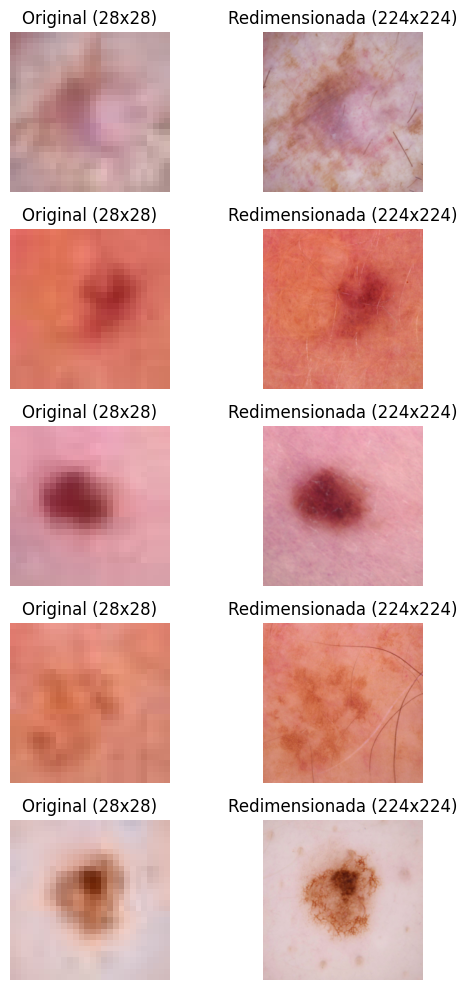

In [ ]:
# --------------------- CONFIGURACIÓN ---------------------
data_flag = 'dermamnist'
download = True
NUM_SAMPLES = 5
IMAGE_SIZE = 224  # Para redimensionar con load_dataset

# Obtener información y clase del dataset
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

# --------------------- TRANSFORMACIONES ---------------------
# Original sin redimensionar (por defecto 28x28)
transform_original = transforms.ToTensor()

# Transformación con redimensionamiento (esto se usará con load_dataset)
data_transform_224 = transforms.Compose([
    transforms.ToTensor()
])

# --------------------- FUNCIÓN PARA DATASET REDIMENSIONADO ---------------------
def load_dataset(split):
    return DataClass(
        split=split,
        transform=data_transform_224,
        download=download,
        size=IMAGE_SIZE,         # 👈 Aquí se define el resize real
        mmap_mode='r'
    )

# --------------------- CARGA DE DATASETS ---------------------
# Dataset original (28x28)
dataset_original = DataClass(split='train', transform=transform_original, download=download)

# Dataset redimensionado (224x224)
dataset_resized = load_dataset('train')

# --------------------- VISUALIZACIÓN ---------------------
fig, axes = plt.subplots(NUM_SAMPLES, 2, figsize=(6, NUM_SAMPLES * 2))

for i in range(NUM_SAMPLES):
    img_orig = dataset_original[i][0]
    img_resize = dataset_resized[i][0]

    # Convertir a formato [H, W, C] para visualización
    img_orig_np = img_orig.permute(1, 2, 0).numpy()
    img_resize_np = img_resize.permute(1, 2, 0).numpy()

    axes[i, 0].imshow(img_orig_np)
    axes[i, 0].set_title("Original (28x28)")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(img_resize_np)
    axes[i, 1].set_title("Redimensionada (224x224)")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

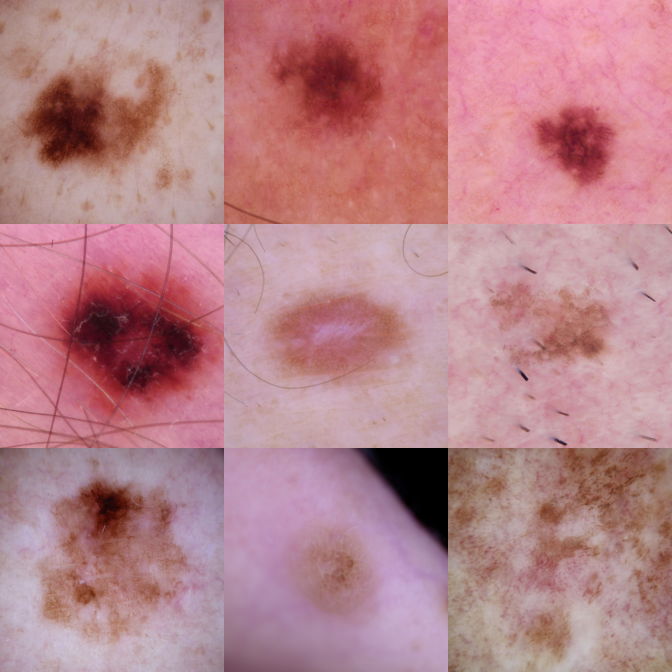

In [ ]:
val_dataset.montage(length=3)

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import imagehash
import numpy as np
import torch # Import torch if it's not already imported in the cell

def tensor_to_pil(tensor):
    array = tensor.numpy()
    array = np.transpose(array, (1, 2, 0))  # [H, W, C]
    # Ensure the array is in the correct format for PIL Image.
    # If the tensor contains float values, scale to 0-255 and convert to uint8.
    if array.dtype != np.uint8:
        array = (array * 255).astype(np.uint8)
    # For grayscale images, remove the last dimension if it's 1
    if array.shape[-1] == 1:
        array = array.squeeze(-1)
    return Image.fromarray(array)

def show_images(img1, img2, distance):
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    # Ensure images are in a format that matplotlib can display (e.g., RGB or grayscale)
    if img1.mode == 'RGB':
        axes[0].imshow(img1)
    else: # Handle grayscale or other modes
        axes[0].imshow(img1, cmap='gray')

    axes[0].set_title("Imagen previa")
    axes[0].axis('off')

    if img2.mode == 'RGB':
        axes[1].imshow(img2)
    else: # Handle grayscale or other modes
        axes[1].imshow(img2, cmap='gray')

    axes[1].set_title(f"Duplicado (dist={distance})")
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

def check_visual_duplicates_with_preview(dataloader, hash_func=imagehash.phash, max_distance=3, max_visuals=5):
    seen_hashes = {}  # hash -> (image PIL, image_id)
    duplicate_count = 0
    total_images = 0
    shown = 0

    dataset = dataloader.dataset # Keep this line to access dataset length if needed

    for batch_idx, (images, labels) in enumerate(dataloader):
        batch_size = images.size(0)

        for i in range(batch_size):
            total_images += 1 # Increment total_images per image, not per batch

            img_tensor = images[i]
            img_pil = tensor_to_pil(img_tensor)

            # Use the real index as a simple identifier
            real_index = batch_idx * dataloader.batch_size + i
            image_id = f"index_{real_index}" # Simple index-based ID

            img_hash = hash_func(img_pil)

            is_duplicate = False
            for prev_hash, (prev_img, prev_id) in seen_hashes.items():
                distance = img_hash - prev_hash
                if distance <= max_distance:
                    duplicate_count += 1
                    is_duplicate = True
                    print(f"🔁 Similar found (dist={distance})")
                    print(f"🆔 Imagen previa ID: {prev_id}")
                    print(f"🆔 Imagen duplicada ID: {image_id}")
                    if shown < max_visuals:
                        show_images(prev_img, img_pil, distance)
                        shown += 1
                    break # Stop checking hashes once a duplicate is found

            if not is_duplicate:
                seen_hashes[img_hash] = (img_pil, image_id)

    print(f"\n🔍 Total imágenes revisadas: {total_images}")
    print(f"🔁 Duplicados visuales encontrados: {duplicate_count}")
    return duplicate_count



# Assuming test_dataset and BATCH_SIZE are defined earlier in your notebook
# test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False) # This line was already present and can remain.

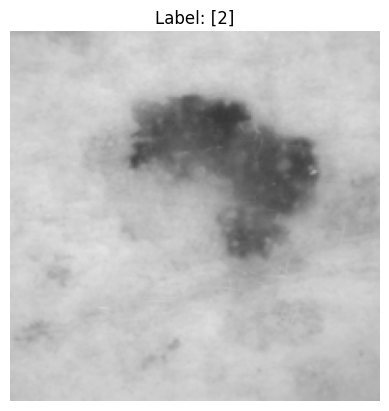

In [ ]:
image, label = train_dataset[10]

#Revertir la normalización para mostrar la imagen correctamente
image = image * 0.5 + 0.5  # Desnormalizar

#Mostrar imagen
import matplotlib.pyplot as plt
plt.imshow(image.permute(1, 2, 0))  # De [C, H, W] a [H, W, C]
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()

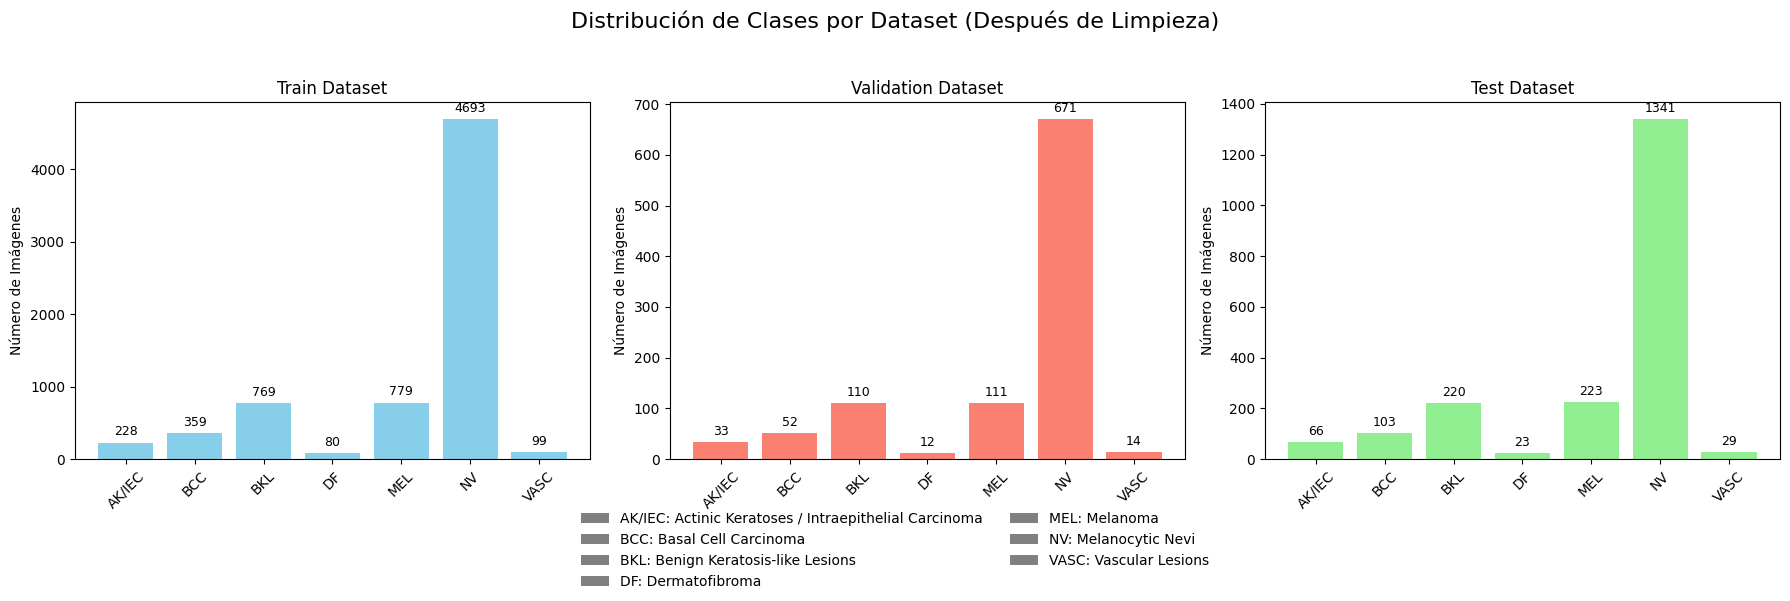

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from torch.utils.data import Subset

# Helper function to get class distribution
def get_class_distribution(dataset):
    """Calculates and returns the distribution of classes in a dataset."""
    if isinstance(dataset, Subset):
        labels = [dataset.dataset[i][1].item() for i in dataset.indices]
    else:
        labels = [dataset[i][1].item() for i in range(len(dataset))]
    classes, counts = np.unique(labels, return_counts=True)
    return classes, counts

# Diccionarios de abreviaciones y nombres completos
class_names_abbrev = {
    '0': 'AK/IEC',
    '1': 'BCC',
    '2': 'BKL',
    '3': 'DF',
    '4': 'MEL',
    '5': 'NV',
    '6': 'VASC'
}

class_names_full = {
    'AK/IEC': 'Actinic Keratoses / Intraepithelial Carcinoma',
    'BCC': 'Basal Cell Carcinoma',
    'BKL': 'Benign Keratosis-like Lesions',
    'DF': 'Dermatofibroma',
    'MEL': 'Melanoma',
    'NV': 'Melanocytic Nevi',
    'VASC': 'Vascular Lesions'
}

# Obtener distribuciones
train_classes, train_counts = get_class_distribution(train_dataset)
val_classes, val_counts = get_class_distribution(val_dataset)
test_classes, test_counts = get_class_distribution(test_dataset)

# Mapear índices a nombres abreviados
train_class_names = [class_names_abbrev[str(int(c))] for c in train_classes]
val_class_names = [class_names_abbrev[str(int(c))] for c in val_classes]
test_class_names = [class_names_abbrev[str(int(c))] for c in test_classes]

# Crear subgráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Distribución de Clases por Dataset (Después de Limpieza)', fontsize=16)

# Función para añadir contadores encima de cada barra
def annotate_bars(ax, bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # separación del texto hacia arriba
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

# Train
bars_train = axes[0].bar(train_class_names, train_counts, color='skyblue')
axes[0].set_title('Train Dataset')
axes[0].set_ylabel('Número de Imágenes')
axes[0].tick_params(axis='x', rotation=45)
annotate_bars(axes[0], bars_train)

# Validation
bars_val = axes[1].bar(val_class_names, val_counts, color='salmon')
axes[1].set_title('Validation Dataset')
axes[1].set_ylabel('Número de Imágenes')
axes[1].tick_params(axis='x', rotation=45)
annotate_bars(axes[1], bars_val)

# Test
bars_test = axes[2].bar(test_class_names, test_counts, color='lightgreen')
axes[2].set_title('Test Dataset')
axes[2].set_ylabel('Número de Imágenes')
axes[2].tick_params(axis='x', rotation=45)
annotate_bars(axes[2], bars_test)

# Leyenda
legend_elements = [Patch(facecolor='gray', label=f'{abbr}: {class_names_full[abbr]}') for abbr in class_names_full]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=10, frameon=False)

plt.tight_layout(rect=[0, 0.12, 1, 0.95])
plt.show()

Modelo 1 (ResNet18 fine-tune + Mahalanobis)

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
import medmnist
from medmnist import INFO

data_flag = 'dermamnist'
download = True
BATCH_SIZE = 64
IMAGE_SIZE = 224

info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

# Transformaciones para entrenamiento y validación
transform_train = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),  # pasar a 3 canales para ResNet
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

transform_val = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

def load_dataset(split, transform):
    return DataClass(split=split, transform=transform, download=download, size=IMAGE_SIZE, mmap_mode='r')

train_dataset = load_dataset('train', transform_train)
val_dataset = load_dataset('val', transform_val)
test_dataset = load_dataset('test', transform_val)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
import torch.nn as nn
from torchvision.models import resnet18

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(info['label'])  # number of classes in the dataset

model = resnet18(pretrained=True)
# Replace the last fully connected layer for our number of classes
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 170MB/s]


In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7,gamma=0.1)

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.squeeze().to(device).long()

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.squeeze().to(device).long()
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss,epoch_acc

In [ ]:
# 📦 Imports
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet18
import medmnist
from medmnist import INFO

# ⚙️ Configuración
data_flag = 'dermamnist'
download = True
BATCH_SIZE = 64
IMAGE_SIZE = 224
num_epochs = 20
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 📄 Información del dataset
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])
num_classes = len(info['label'])

# 🔄 Transformaciones
transform_train = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

transform_val = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

# 📥 Función para cargar datasets
def load_dataset(split, transform):
    return DataClass(split=split, transform=transform, download=download)

# 📚 Cargar datasets
train_dataset = load_dataset('train', transform_train)
val_dataset   = load_dataset('val', transform_val)
test_dataset  = load_dataset('test', transform_val)

# 📦 DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 🧠 Modelo
model = resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

# ⚙️ Loss, optimizer y scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

# 🔁 Funciones de entrenamiento y validación
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.squeeze().to(device).long()
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.squeeze().to(device).long()
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total

# 🚀 Entrenamiento
for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    scheduler.step()

# ✅ Evaluación final
test_loss, test_acc = validate(model, test_loader, criterion, device)
print("\n✅ Evaluación final en Test:")
print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")


100%|██████████| 19.7M/19.7M [00:31<00:00, 617kB/s]
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/20
Train Loss: 1.0168 | Train Acc: 0.6690
Val Loss:   0.7990 | Val Acc:   0.7348
Epoch 2/20
Train Loss: 0.8043 | Train Acc: 0.7237
Val Loss:   0.7856 | Val Acc:   0.7288
Epoch 3/20
Train Loss: 0.7375 | Train Acc: 0.7400
Val Loss:   0.7968 | Val Acc:   0.7248
Epoch 4/20
Train Loss: 0.6838 | Train Acc: 0.7535
Val Loss:   0.7566 | Val Acc:   0.7398
Epoch 5/20
Train Loss: 0.5939 | Train Acc: 0.7861
Val Loss:   0.8648 | Val Acc:   0.7168
Epoch 6/20
Train Loss: 0.5185 | Train Acc: 0.8132
Val Loss:   0.8080 | Val Acc:   0.7278
Epoch 7/20
Train Loss: 0.4353 | Train Acc: 0.8456
Val Loss:   0.8905 | Val Acc:   0.7198
Epoch 8/20
Train Loss: 0.2956 | Train Acc: 0.9045
Val Loss:   0.8051 | Val Acc:   0.7348
Epoch 9/20
Train Loss: 0.2428 | Train Acc: 0.9279
Val Loss:   0.8190 | Val Acc:   0.7338
Epoch 10/20
Train Loss: 0.2130 | Train Acc: 0.9396
Val Loss:   0.8254 | Val Acc:   0.7318
Epoch 11/20
Train Loss: 0.1982 | Train Acc: 0.9426
Val Loss:   0.8438 | Val Acc:   0.7278
Epoch 12/20
Train L

In [ ]:
# Quitar la capa final para usar como extractor de características
extractor = nn.Sequential(*list(model.children())[:-1])  # Quita fc
extractor = extractor.to(device)
extractor.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [ ]:
def get_embeddings(loader, extractor):
    features, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.squeeze().numpy()

            out = extractor(x).squeeze()  # salida [B, 512, 1, 1] → [B, 512]
            if out.ndim == 1:  # en caso de batch size = 1
                out = out.unsqueeze(0)

            features.append(out.cpu().numpy())
            labels.append(y)

    return np.vstack(features), np.hstack(labels)

In [ ]:
from sklearn.covariance import EmpiricalCovariance

train_features, train_labels = get_embeddings(train_loader, extractor)

classes = np.unique(train_labels)
class_means = {}
class_covs = []

for c in classes:
    cls_feat = train_features[train_labels == c]
    class_means[c] = cls_feat.mean(axis=0)
    class_covs.append(cls_feat)

all_features = np.vstack(class_covs)
cov_estimator = EmpiricalCovariance().fit(all_features)
inv_cov = cov_estimator.precision_

In [ ]:
def mahalanobis_distance(x, mean, inv_cov):
    delta = x - mean
    return np.sqrt(np.dot(np.dot(delta, inv_cov), delta.T))

def predict_mahalanobis(features):
    preds = []
    for x in features:
        distances = [mahalanobis_distance(x, class_means[c], inv_cov) for c in classes]
        preds.append(np.argmin(distances))
    return np.array(preds)

In [ ]:
val_features, val_labels = get_embeddings(val_loader, extractor)
val_preds = predict_mahalanobis(val_features)
val_acc = (val_preds == val_labels).mean()

print(f"[Validación Mahalanobis] Accuracy: {val_acc:.4f}")

[Validación Mahalanobis] Accuracy: 0.7168


In [ ]:
# prompt: con los datos anteriores calculame precision    recall  f1-score   support, accuracy

from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Get predictions and true labels from the test set
model.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.squeeze().to(device).long()
        outputs = model(images)
        _, predicted = outputs.max(1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

# Calculate and print classification report
print("\n📊 Reporte de Clasificación en Test:")
print(classification_report(all_labels, all_preds, target_names=info['label']))

# Calculate and print accuracy
accuracy = accuracy_score(all_labels, all_preds)
print(f"\n🎯 Accuracy en Test: {accuracy:.4f}")



📊 Reporte de Clasificación en Test:
              precision    recall  f1-score   support

           0       0.43      0.33      0.38        66
           1       0.59      0.48      0.53       103
           2       0.41      0.34      0.37       220
           3       0.57      0.35      0.43        23
           4       0.48      0.30      0.37       223
           5       0.81      0.92      0.87      1341
           6       0.29      0.07      0.11        29

    accuracy                           0.73      2005
   macro avg       0.51      0.40      0.44      2005
weighted avg       0.70      0.73      0.71      2005


🎯 Accuracy en Test: 0.7302


MODELO 2: (ResNetEmbedder + Mahalanobis)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models
import medmnist
from medmnist import INFO
import numpy as np
from tqdm import tqdm
from sklearn.metrics import classification_report, accuracy_score
from scipy.spatial.distance import mahalanobis
from sklearn.decomposition import PCA

# ---------------- CONFIG ----------------
data_flag = 'dermamnist'
NUM_CLASSES = 7
BATCH_SIZE = 64
EPOCHS = 10
LR = 1e-4
IMAGE_SIZE = 64
EMBEDDING_DIM = 128  # tamaño del embedding final

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------- DATA ----------------
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.7637, 0.5379, 0.5605], std=[0.0877, 0.1213, 0.1372])
])

def load_dataset(split):
    return DataClass(split=split, transform=transform, download=True, size=IMAGE_SIZE, mmap_mode='r')

train_loader = DataLoader(load_dataset('train'), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(load_dataset('val'), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(load_dataset('test'), batch_size=BATCH_SIZE, shuffle=False)

# ---------------- MODEL ----------------
class ResNetEmbedder(nn.Module):
    def __init__(self, embed_dim, num_classes):
        super().__init__()
        backbone = models.resnet18(pretrained=True)
        num_ftrs = backbone.fc.in_features
        backbone.fc = nn.Identity()  # Remover la capa final
        self.backbone = backbone
        self.embedding_layer = nn.Linear(num_ftrs, embed_dim)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x, return_embedding=False):
        features = self.backbone(x)
        embedding = self.embedding_layer(features)
        if return_embedding:
            return embedding
        return self.classifier(embedding)

model = ResNetEmbedder(EMBEDDING_DIM, NUM_CLASSES).to(device)

# ---------------- TRAIN ----------------
optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for images, targets in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{EPOCHS}"):
        images, targets = images.to(device), targets.squeeze().long().to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch + 1} - Loss: {avg_loss:.4f}")

# ---------------- SAVE MODEL ----------------
torch.save(model.state_dict(), "resnet_mahalanobis.pth")
print("✅ Modelo guardado!")

# ---------------- EXTRACT EMBEDDINGS ----------------
def extract_embeddings(loader):
    embeddings, labels = [], []
    model.eval()
    with torch.no_grad():
        for images, targets in tqdm(loader, desc="Extrayendo embeddings"):
            images = images.to(device)
            embs = model(images, return_embedding=True)
            embeddings.append(embs.cpu().numpy())
            labels.append(targets.squeeze().cpu().numpy())
    return np.vstack(embeddings), np.concatenate(labels)

X_train, y_train = extract_embeddings(train_loader)
X_val, y_val = extract_embeddings(val_loader)
X_test, y_test = extract_embeddings(test_loader)

# ---------------- OPCIONAL: PCA ----------------
pca = PCA(n_components=64)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# ---------------- CLASS MEANS ----------------
class_means = np.array([X_train_pca[y_train == c].mean(axis=0) for c in np.unique(y_train)])

# ---------------- COVARIANCE ----------------
cov_matrix = np.cov(X_train_pca.T)
cov_inv = np.linalg.pinv(cov_matrix)

# ---------------- MAHALANOBIS PREDICTION ----------------
y_pred = []
for x in tqdm(X_test_pca, desc="Clasificando con Mahalanobis"):
    distances = [mahalanobis(x, m, cov_inv) for m in class_means]
    y_pred.append(np.argmin(distances))

# ---------------- METRICS ----------------
acc = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, digits=4)

print(f"\n✅ Accuracy (Mahalanobis): {acc:.4f}")
print("\n📄 Reporte de clasificación:\n", report)


100%|██████████| 100M/100M [00:06<00:00, 15.7MB/s] 
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/10: 100%|██████████| 110/110 [00:06<00:00, 17.97it/s]


Epoch 1 - Loss: 0.7984


Epoch 2/10: 100%|██████████| 110/110 [00:05<00:00, 20.30it/s]


Epoch 2 - Loss: 0.4109


Epoch 3/10: 100%|██████████| 110/110 [00:05<00:00, 19.09it/s]


...

Epoch 9 - Loss: 0.0528


Epoch 10/10: 100%|██████████| 110/110 [00:05<00:00, 18.96it/s]


Epoch 10 - Loss: 0.0443
✅ Modelo guardado!


Clasificando con Mahalanobis: 100%|██████████| 2005/2005 [00:00<00:00, 13945.96it/s]



✅ Accuracy (Mahalanobis): 0.7940

📄 Reporte de clasificación:
               precision    recall  f1-score   support

           0     0.5102    0.3788    0.4348        66
           1     0.6500    0.6311    0.6404       103
           2     0.6647    0.5136    0.5795       220
           3     0.6154    0.3478    0.4444        23
           4     0.5596    0.4843    0.5192       223
           5     0.8605    0.9381    0.8976      1341
           6     0.8333    0.5172    0.6383        29

    accuracy                         0.7940      2005
   macro avg     0.6705    0.5444    0.5935      2005
weighted avg     0.7800    0.7940    0.7832      2005

